# Capstone Project : Unsupervised Learning

## Patient Stratification Using K-means Clustering and PCA

      Authored by Eliud Mule

## Task 1: Data Import and Initial Exploration

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, fetch_openml
from sklearn.preprocessing import StandardScaler
from scipy.stats import f_oneway, chi2_contingency, kruskal
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
import umap


In [2]:
# Import data
df = pd.read_csv('medical_clustering_data.csv')
df.head(6)   # display first six rows


,patient_id,age,sex,bmi,waist_cm,bp_systolic,bp_diastolic,heart_rate,cholesterol_total,cholesterol_hdl,cholesterol_ldl,triglycerides,glucose_fasting,hba1c,crp,smoking_status,alcohol_drinks_week,physical_activity_min_week,risk_score,metabolic_syndrome
0,PT-001,59,Male,17.3,138.8,153.0,96,88,154.6,54.1,60.6,83.90,NaN,5.56,0.20,Current,5,145.0,11.8,0
1,PT-002,37,Female,27.6,140.0,103.0,72,50,189.7,69.2,89.1,38.10,87.7,5.34,2.30,Never,2,87.0,0.3,0
2,PT-003,54,Female,23.0,NaN,117.0,71,89,269.5,30.2,200.8,NaN,105.0,NaN,0.20,Never,6,268.0,9.1,1
3,PT-004,51,Female,22.8,140.0,508.8,104,89,222.5,59.2,132.0,64.00,NaN,5.99,28.69,Never,6,45.0,11.5,0
4,PT-005,43,Female,23.5,140.0,125.0,87,86,140.5,43.2,59.7,130.56,96.0,5.38,2.14,Current,6,177.0,7.4,1
5,PT-006,18,Male,29.4,140.0,157.0,117,71,159.6,40.9,94.0,41.40,68.5,4.69,0.31,Never,3,39.0,10.5,0


In [3]:
#Data structure
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   patient_id                  220 non-null    object 
 1   age                         220 non-null    int64  
 2   sex                         220 non-null    object 
 3   bmi                         202 non-null    float64
 4   waist_cm                    202 non-null    float64
 5   bp_systolic                 220 non-null    float64
 6   bp_diastolic                220 non-null    int64  
 7   heart_rate                  220 non-null    int64  
 8   cholesterol_total           220 non-null    float64
 9   cholesterol_hdl             202 non-null    float64
 10  cholesterol_ldl             220 non-null    float64
 11  triglycerides               202 non-null    float64
 12  glucose_fasting             202 non-null    float64
 13  hba1c                       202 non

In [4]:
# Summary Statistics
df.describe()

,age,bmi,waist_cm,bp_systolic,bp_diastolic,heart_rate,cholesterol_total,cholesterol_hdl,cholesterol_ldl,triglycerides,glucose_fasting,hba1c,crp,alcohol_drinks_week,physical_activity_min_week,risk_score,metabolic_syndrome
count,220.000000,202.000000,202.000000,220.000000,220.000000,220.000000,220.000000,202.000000,220.000000,202.000000,202.000000,202.000000,202.000000,220.000000,202.000000,220.000000,220.00000
mean,52.409091,28.871287,139.034653,136.514091,86.504545,70.936364,196.874545,48.002970,115.548182,83.545050,105.610693,5.438317,2.020856,4.468182,192.787129,6.680909,0.50000
std,13.722824,11.280907,3.190360,57.619915,13.103904,11.960572,39.952441,13.344248,42.221077,58.220374,46.770429,0.628907,2.925588,2.150478,215.468342,3.417134,0.50114
min,18.000000,16.000000,123.200000,90.000000,55.000000,50.000000,81.800000,9.200000,40.000000,15.100000,60.000000,4.000000,0.070000,0.000000,8.000000,0.000000,0.00000
25%,42.000000,23.550000,140.000000,116.000000,77.000000,62.000000,170.225000,39.075000,87.350000,44.125000,86.050000,5.042500,0.472500,3.000000,53.000000,4.575000,0.00000
50%,52.000000,28.250000,140.000000,126.000000,86.000000,70.000000,196.250000,48.250000,115.200000,69.550000,100.750000,5.400000,1.000000,4.000000,108.000000,6.500000,0.50000
75%,61.000000,31.275000,140.000000,139.000000,95.000000,80.000000,222.600000,56.475000,144.725000,107.175000,115.175000,5.875000,2.262500,6.000000,242.250000,8.625000,1.00000
max,85.000000,125.460000,140.000000,508.800000,120.000000,101.000000,306.000000,82.400000,220.300000,447.720000,442.560000,6.930000,28.690000,11.000000,1000.000000,20.300000,1.00000


In [5]:
# Checking for Missing values
print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
print(f"\nMissing values per column:\n{df.isnull().sum()}")
print(f"\nMissing value percentage:\n{(df.isnull().sum() / len(df) * 100).round(2)}")


MISSING VALUES

Missing values per column:
patient_id                     0
age                            0
sex                            0
bmi                           18
waist_cm                      18
bp_systolic                    0
bp_diastolic                   0
heart_rate                     0
cholesterol_total              0
cholesterol_hdl               18
cholesterol_ldl                0
triglycerides                 18
glucose_fasting               18
hba1c                         18
crp                           18
smoking_status                 0
alcohol_drinks_week            0
physical_activity_min_week    18
risk_score                     0
metabolic_syndrome             0
dtype: int64

Missing value percentage:
patient_id                    0.00
age                           0.00
sex                           0.00
bmi                           8.18
waist_cm                      8.18
bp_systolic                   0.00
bp_diastolic                  0.00
heart_rate 

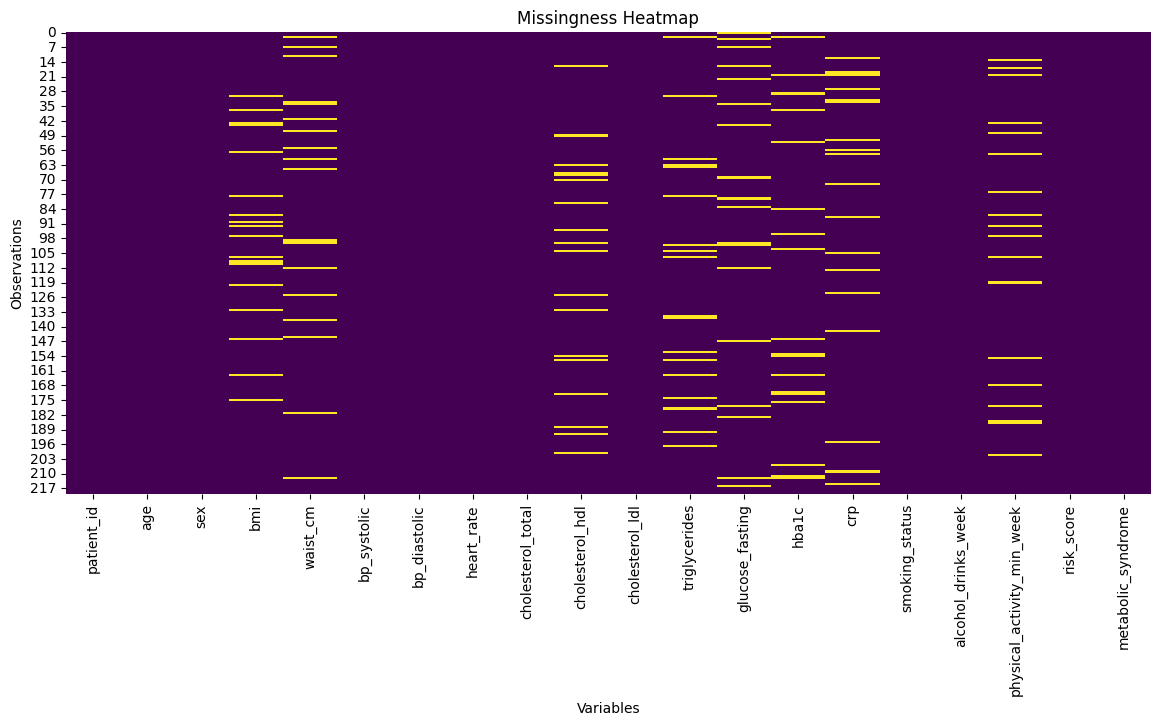

In [6]:
# ---------------------------------------------------------
# 4. Missingness Heatmap
# ---------------------------------------------------------

plt.figure(figsize=(14,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title('Missingness Heatmap')
plt.xlabel('Variables')
plt.ylabel('Observations')

plt.show()


## Task 2 : Data Preprocessing

In [7]:
# ---------------------------------------------------------
# 1. Missing Data Handling
# ---------------------------------------------------------

# RATIONALE:
# - Variables with >15% missing values will be removed
# - Numeric variables with moderate missingness: median imputation (robust to skewness/outliers)

# Calculate missing percentages
missing_percent = (df.isnull().sum() / len(df)) * 100

# Drop columns with >15% missing
cols_to_drop = missing_percent[missing_percent > 15].index

print("\nColumns removed (>15% missing):")
print(cols_to_drop)

df = df.drop(columns=cols_to_drop)

# Separate numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Median imputation
imputer = SimpleImputer(strategy='median')

df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

print("\nMissing values after imputation:")
print(df.isnull().sum())


Columns removed (>15% missing):
Index([], dtype='object')

Missing values after imputation:
patient_id                    0
age                           0
sex                           0
bmi                           0
waist_cm                      0
bp_systolic                   0
bp_diastolic                  0
heart_rate                    0
cholesterol_total             0
cholesterol_hdl               0
cholesterol_ldl               0
triglycerides                 0
glucose_fasting               0
hba1c                         0
crp                           0
smoking_status                0
alcohol_drinks_week           0
physical_activity_min_week    0
risk_score                    0
metabolic_syndrome            0
dtype: int64


In [8]:
# ---------------------------------------------------------
# 2. Outlier Detection using IQR
# ---------------------------------------------------------

outlier_summary = {}

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_summary[col] = len(outliers)

# Convert to dataframe
outlier_table = pd.DataFrame.from_dict(
    outlier_summary,
    orient='index',
    columns=['Outlier_Count']
)

outlier_table = outlier_table.sort_values(
    by='Outlier_Count',
    ascending=False
)

print("\nOUTLIER SUMMARY")
display(outlier_table)




OUTLIER SUMMARY


,Outlier_Count
crp,28
waist_cm,24
physical_activity_min_week,23
triglycerides,11
bp_systolic,8
cholesterol_hdl,6
glucose_fasting,6
hba1c,5
bmi,5
risk_score,4


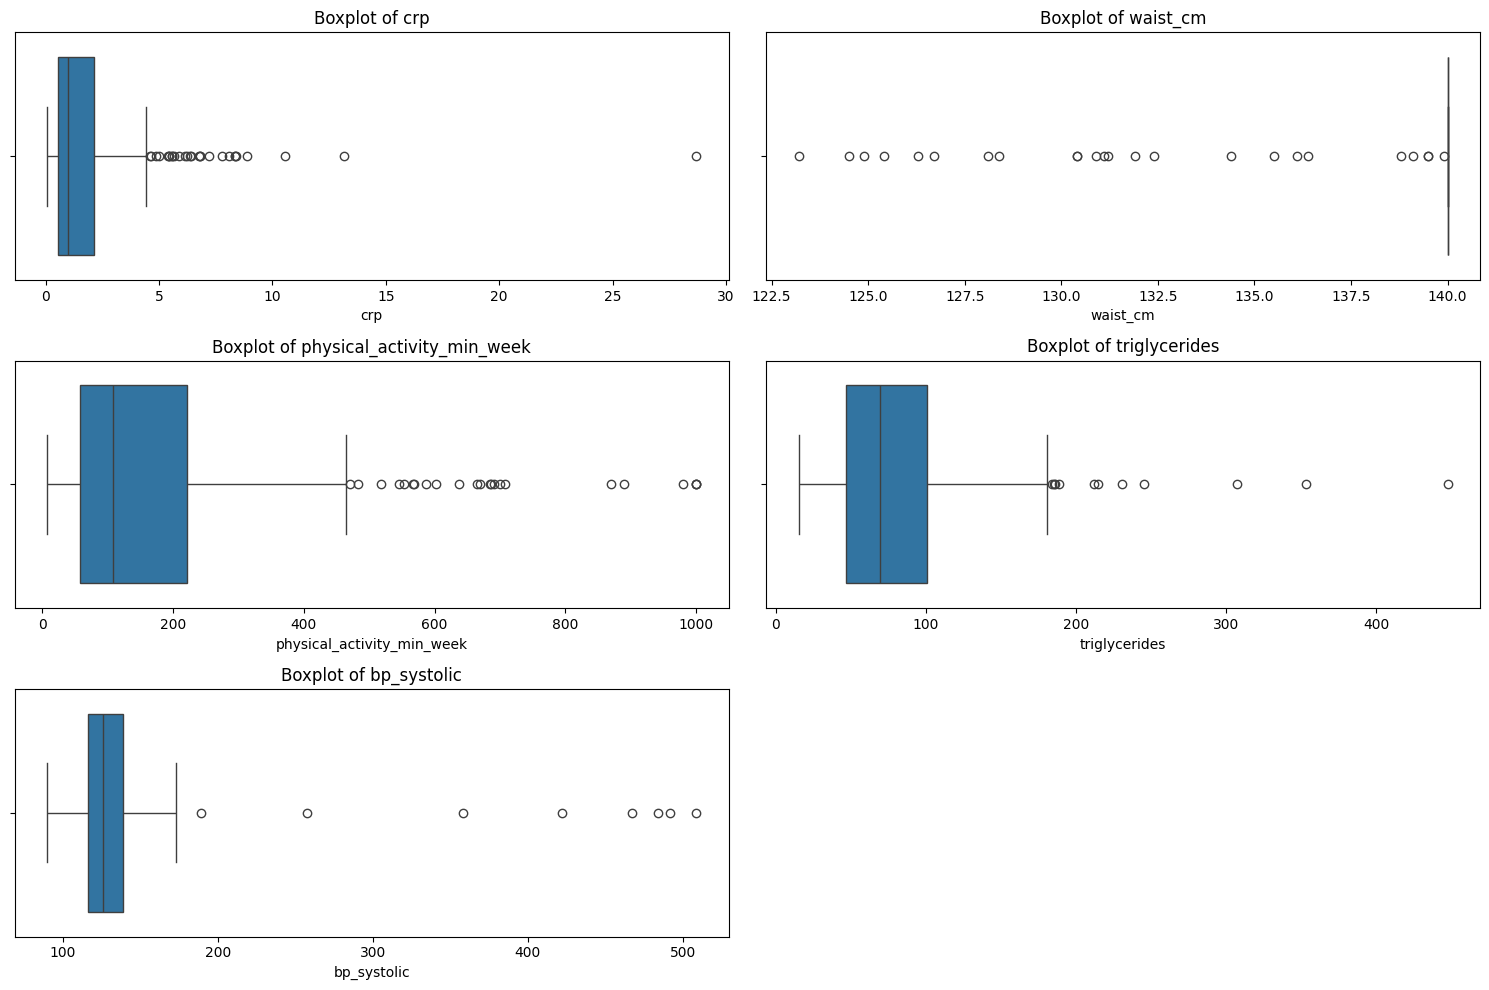

In [9]:
# ---------------------------------------------------------
# Boxplots for top 5 variables with most outliers
# ---------------------------------------------------------

top5_outliers = outlier_table.head(5).index

plt.figure(figsize=(15,10))

for i, col in enumerate(top5_outliers, 1):

    plt.subplot(3,2,i)

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [10]:
# ---------------------------------------------------------
# 3. Outlier Treatment - Winsorization
# ---------------------------------------------------------

# Winsorization caps extreme values without removing data, preserving observations for clustering.

for col in numeric_cols:

    lower_cap = np.percentile(df[col], 1)
    upper_cap = np.percentile(df[col], 99)

    df[col] = np.clip(
        df[col],
        lower_cap,
        upper_cap
    )

print("\nWinsorization completed.")


Winsorization completed.


In [11]:
# ---------------------------------------------------------
# 4. Feature Scaling
# ---------------------------------------------------------

# Exclude non-clustering variables
exclude_cols = [
    'patient_id',
    'sex',
    'smoking_status',
    'risk_score',
    'metabolic_syndrome'
]

# Keep only available columns
exclude_cols = [col for col in exclude_cols if col in df.columns]

cluster_features = [
    col for col in numeric_cols
    if col not in exclude_cols
]

# Standardization
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df[cluster_features])

medical_clean = pd.DataFrame(
    scaled_data,
    columns=cluster_features
)

print("\nCLEANED & SCALED DATASET")
display(medical_clean.head())


CLEANED & SCALED DATASET


,age,bmi,waist_cm,bp_systolic,bp_diastolic,heart_rate,cholesterol_total,cholesterol_hdl,cholesterol_ldl,triglycerides,glucose_fasting,hba1c,crp,alcohol_drinks_week,physical_activity_min_week
0,0.483665,-1.394402,-0.107876,0.296382,0.728045,1.442230,-1.090002,0.483649,-1.306333,0.049160,-0.096167,0.208422,-0.758773,0.254957,-0.197086
1,-1.144247,-0.104197,0.291077,-0.592063,-1.119688,-1.763092,-0.188702,1.689853,-0.628312,-0.856465,-0.411375,-0.158937,0.213416,-1.176289,-0.477225
2,0.113685,-0.680405,0.291077,-0.343298,-1.196676,1.526581,1.860406,-1.425507,2.029053,-0.234589,0.006487,-0.058748,-0.758773,0.732039,0.397002
3,-0.108303,-0.705458,0.291077,6.118291,1.343956,1.526581,0.653538,0.891043,0.392287,-0.344332,-0.096167,0.926442,3.894218,0.732039,-0.680085
4,-0.700271,-0.617774,0.291077,-0.201147,0.035145,1.273529,-1.452062,-0.387054,-1.327744,0.971790,-0.210898,-0.092144,0.139345,0.732039,-0.042527


## Task 3 : Exploratory Data Visualization

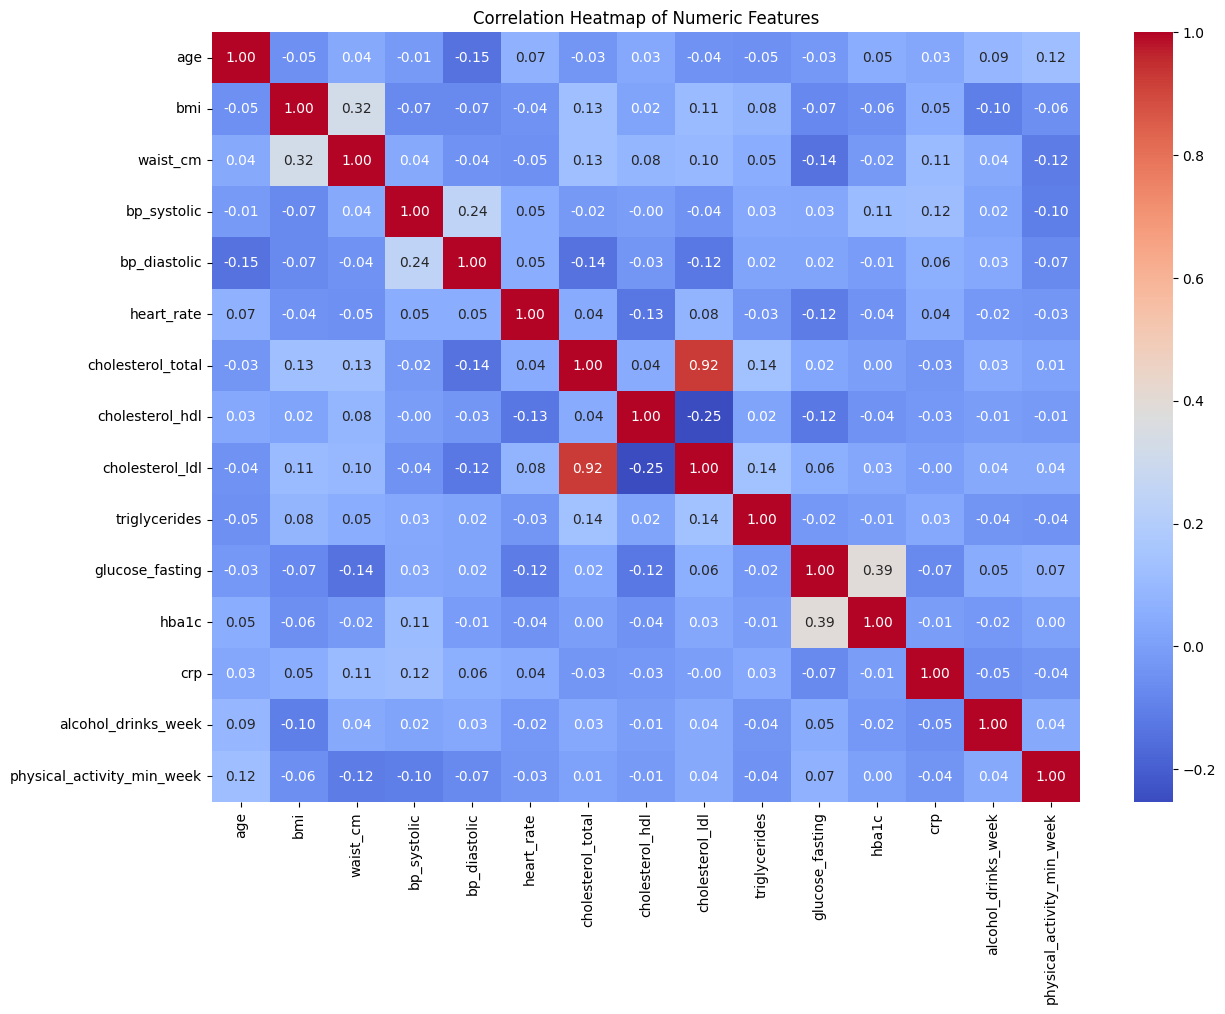

In [12]:
# ---------------------------------------------------------
# 1. Correlation Heatmap
# ---------------------------------------------------------

corr_matrix = medical_clean.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numeric Features')

plt.show()

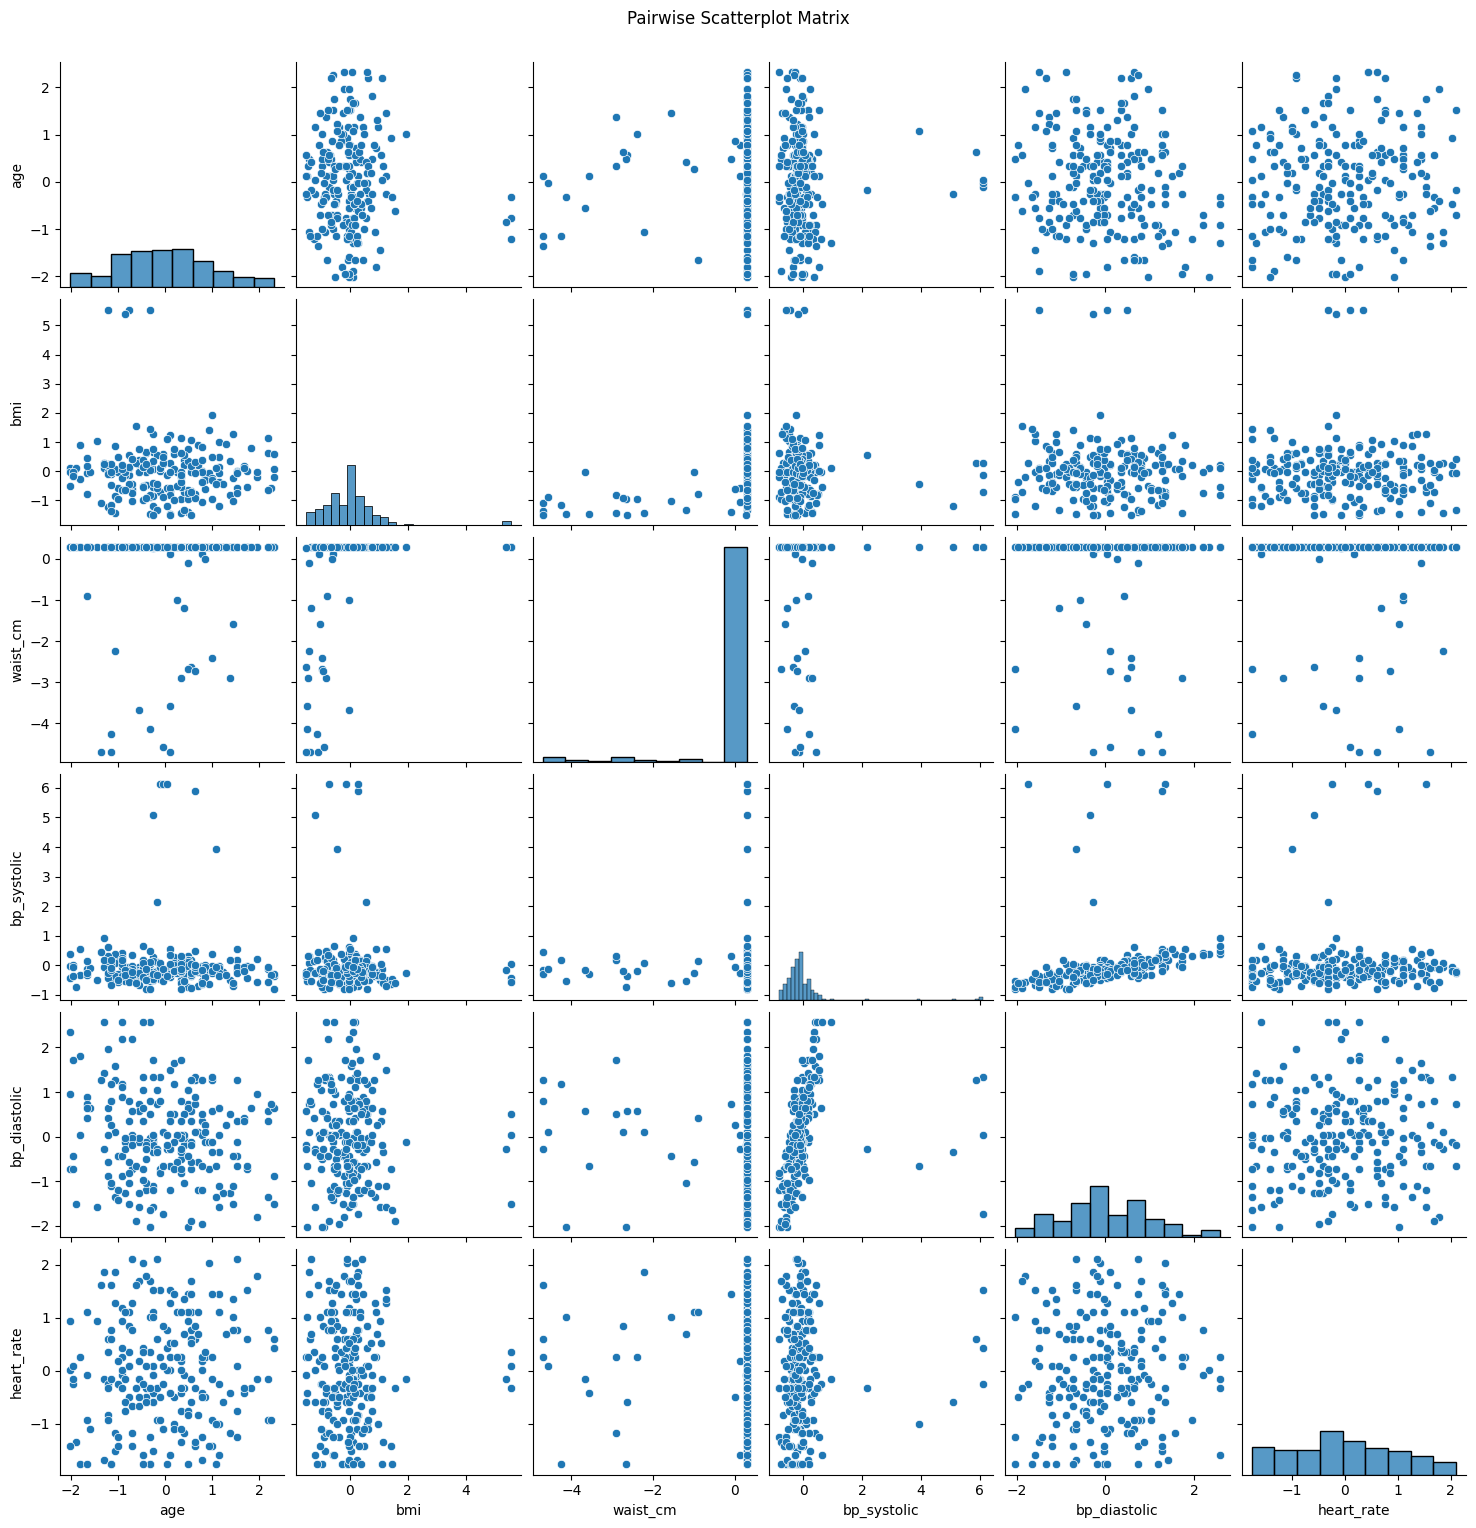

In [13]:
# ---------------------------------------------------------
# 2. Pairwise Scatterplot Matrix
# ---------------------------------------------------------

top6_vars = medical_clean.columns[:6]

sns.pairplot(
    medical_clean[top6_vars]
)

plt.suptitle(
    'Pairwise Scatterplot Matrix',
    y=1.02
)

plt.show()

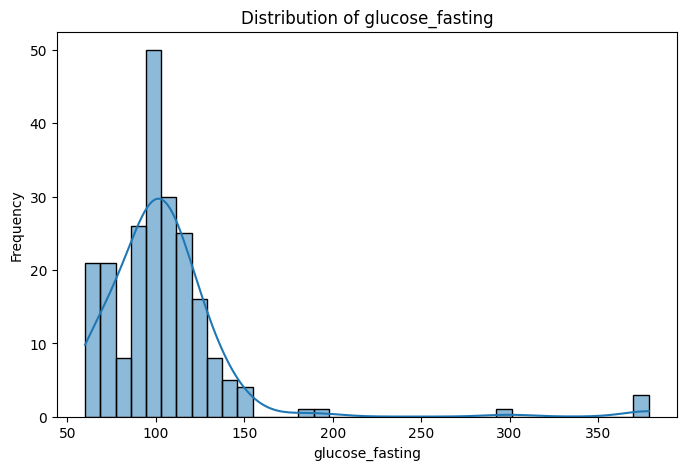

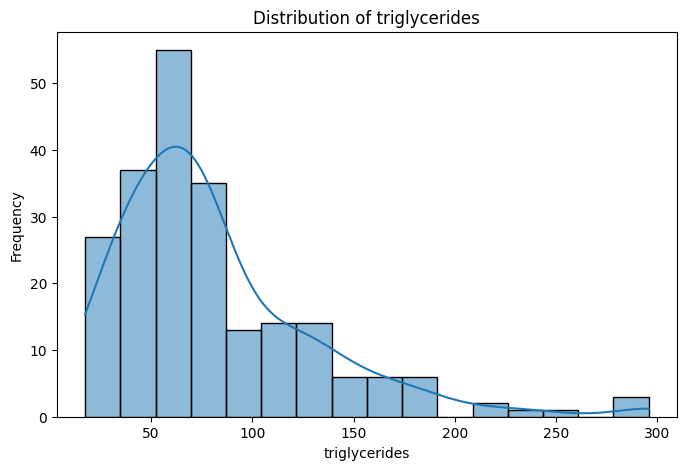

In [14]:
# ---------------------------------------------------------
# 3. Distribution Plots
# ---------------------------------------------------------

dist_vars = [
    'BMI',
    'glucose_fasting',
    'triglycerides'
]

# Keep only variables existing in dataset
dist_vars = [v for v in dist_vars if v in df.columns]

for col in dist_vars:

    plt.figure(figsize=(8,5))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.show()

In [31]:
# ---------------------------------------------------------
# 4. Group Comparisons by Sex
# ---------------------------------------------------------

# Cohen's d function
def cohens_d(group1, group2):

    mean1 = np.mean(group1)
    mean2 = np.mean(group2)

    sd1 = np.std(group1, ddof=1)
    sd2 = np.std(group2, ddof=1)

    pooled_sd = np.sqrt(
        ((sd1**2) + (sd2**2)) / 2
    )

    d = (mean1 - mean2) / pooled_sd

    return d

group_vars = ['LDL', 'CRP']

group_vars = [v for v in group_vars if v in df.columns]

for col in group_vars:

    plt.figure(figsize=(7,5))

    sns.boxplot(
        x='sex',
        y=col,
        data=df
    )

    plt.title(f'{col} by Sex')
    plt.xlabel('Sex')
    plt.ylabel(col)

    plt.show()

    # Cohen's d
    males = df[df['sex'] == 'Male'][col]
    females = df[df['sex'] == 'Female'][col]

    d = cohens_d(males, females)

    print(f"Cohen's d for {col}: {d:.3f}")


## Task 4 : Principal Component Analysis

In [16]:
# ---------------------------------------------------------
# 1. Perform PCA
# ---------------------------------------------------------

pca = PCA()

pca_data = pca.fit_transform(medical_clean)

# Variance explained
explained_variance = pca.explained_variance_ratio_

# First 5 principal components
pca_variance_table = pd.DataFrame({
    'Principal_Component': [f'PC{i+1}' for i in range(5)],
    'Variance_Explained': explained_variance[:5],
    'Cumulative_Variance': np.cumsum(explained_variance[:5])
})

print("\nPCA VARIANCE EXPLAINED")
display(pca_variance_table)



PCA VARIANCE EXPLAINED


,Principal_Component,Variance_Explained,Cumulative_Variance
0,PC1,0.139941,0.139941
1,PC2,0.107380,0.247321
2,PC3,0.095120,0.342442
3,PC4,0.085311,0.427752
4,PC5,0.077704,0.505456


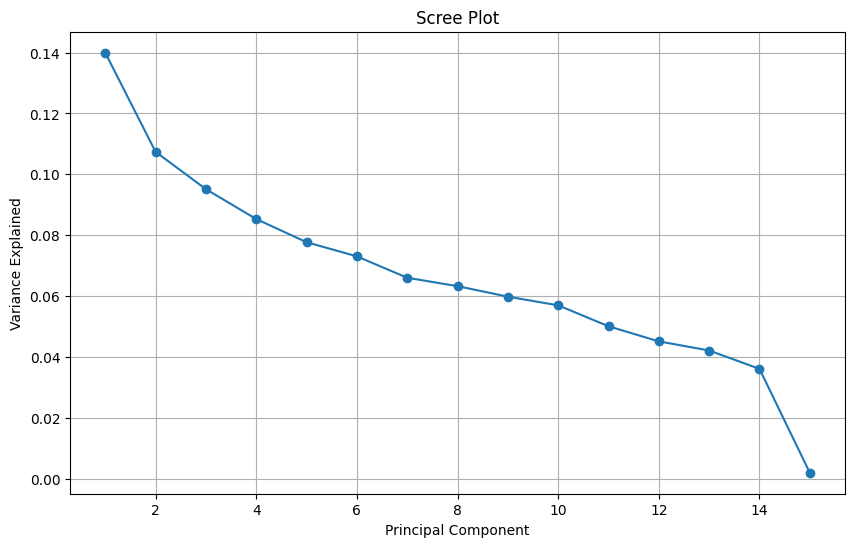

In [17]:
# ---------------------------------------------------------
# 2. Scree Plot
# ---------------------------------------------------------

plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance,
    marker='o'
)

plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Scree Plot')

plt.grid(True)

plt.show()


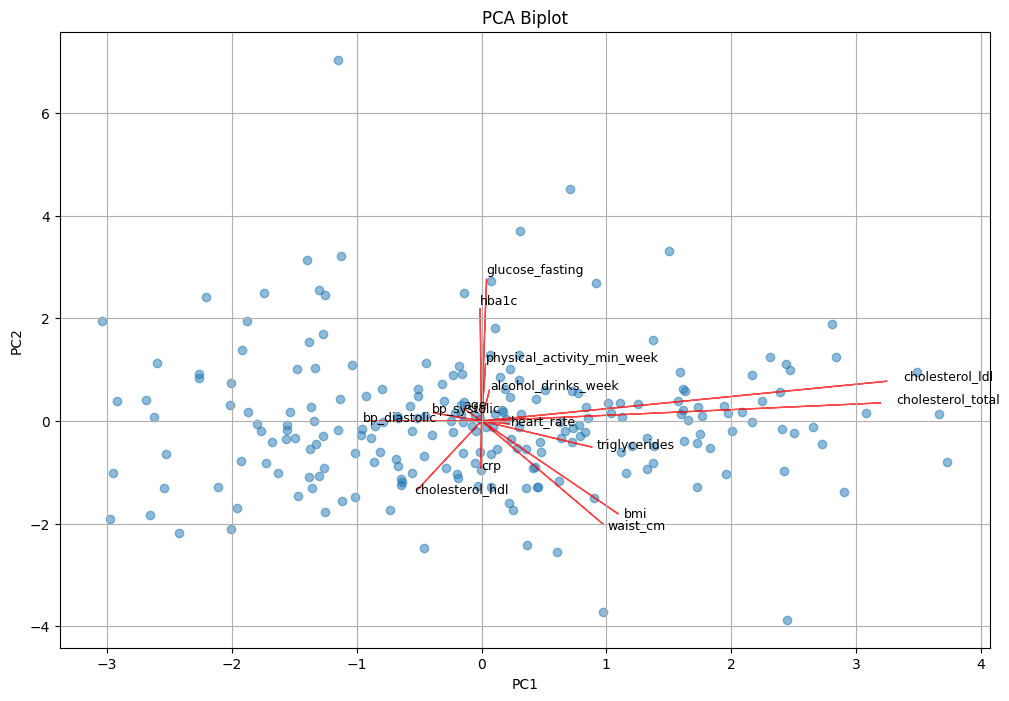

In [18]:
# ---------------------------------------------------------
# 3. PCA Biplot (PC1 vs PC2)
# ---------------------------------------------------------

# PCA dataframe
pca_df = pd.DataFrame(
    pca_data[:, :2],
    columns=['PC1', 'PC2']
)

# Loadings
loadings = pca.components_.T

plt.figure(figsize=(12,8))

# Scatter plot
plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    alpha=0.5
)

# Variable arrows
for i, feature in enumerate(medical_clean.columns):

    plt.arrow(
        0,
        0,
        loadings[i,0]*5,
        loadings[i,1]*5,
        color='red',
        alpha=0.7
    )

    plt.text(
        loadings[i,0]*5.2,
        loadings[i,1]*5.2,
        feature,
        fontsize=9
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Biplot')

plt.grid(True)

plt.show()

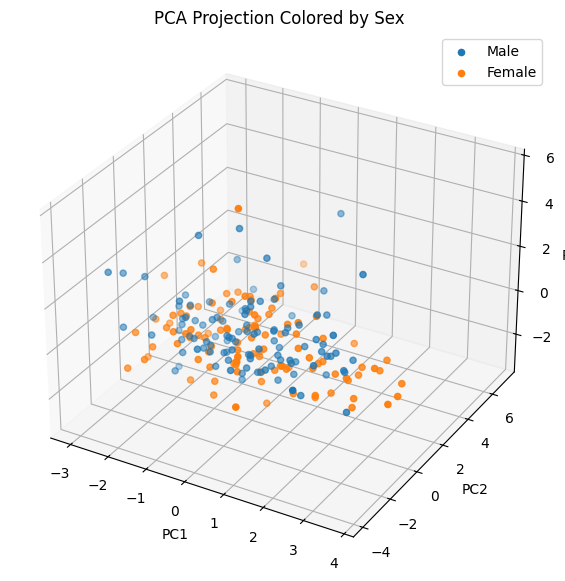

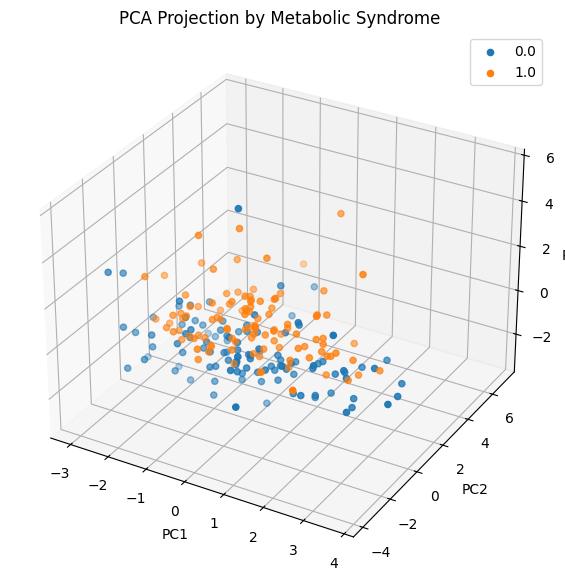

In [19]:
# ---------------------------------------------------------
# 4. PC1-PC3 Projection by Sex & Metabolic Syndrome
# ---------------------------------------------------------

pca_3d = pd.DataFrame(
    pca_data[:, :3],
    columns=['PC1', 'PC2', 'PC3']
)

# Add external variables
if 'sex' in df.columns:
    pca_3d['sex'] = df['sex']

if 'metabolic_syndrome' in df.columns:
    pca_3d['metabolic_syndrome'] = df['metabolic_syndrome']

# ---- By Sex ----
fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111, projection='3d')

for sex in pca_3d['sex'].unique():

    subset = pca_3d[pca_3d['sex'] == sex]

    ax.scatter(
        subset['PC1'],
        subset['PC2'],
        subset['PC3'],
        label=sex
    )

ax.set_title('PCA Projection Colored by Sex')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

ax.legend()

plt.show()

# ---- By Metabolic Syndrome ----
fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111, projection='3d')

for status in pca_3d['metabolic_syndrome'].unique():

    subset = pca_3d[
        pca_3d['metabolic_syndrome'] == status
    ]

    ax.scatter(
        subset['PC1'],
        subset['PC2'],
        subset['PC3'],
        label=status
    )

ax.set_title('PCA Projection by Metabolic Syndrome')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

ax.legend()

plt.show()

In [20]:
# ---------------------------------------------------------
# 5. Cumulative Variance Explained
# ---------------------------------------------------------

cumulative_variance = np.cumsum(explained_variance)
print(cumulative_variance)
pcs_needed = np.argmax(cumulative_variance >= 0.85) + 1

print(f"\nNumber of PCs needed for >=85% variance: {pcs_needed}")



[0.13994138 0.24732131 0.34244163 0.42775215 0.5054564  0.578511
 0.64453274 0.70779909 0.76761033 0.82457523 0.87466187 0.91978777
 0.96191579 0.99801815 1.        ]

Number of PCs needed for >=85% variance: 11


## Task 5 : K-means Clustering Implementation

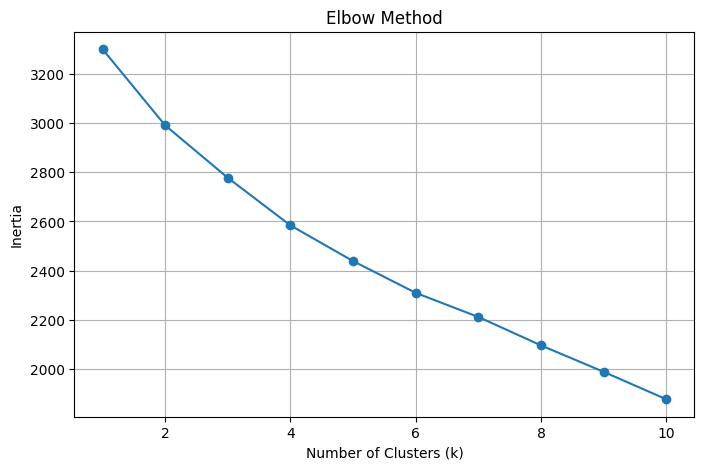

In [21]:
# ---------------------------------------------------------
# 1. Optimal k Selection
# ---------------------------------------------------------

inertia = []
silhouette_scores = []

k_values = range(1, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=2026,
        n_init=25
    )

    kmeans.fit(medical_clean)

    inertia.append(kmeans.inertia_)

    if k > 1:

        score = silhouette_score(
            medical_clean,
            kmeans.labels_
        )

        silhouette_scores.append(score)

# ---- Elbow Plot ----
plt.figure(figsize=(8,5))

plt.plot(k_values, inertia, marker='o')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

plt.title('Elbow Method')

plt.grid(True)

plt.show()



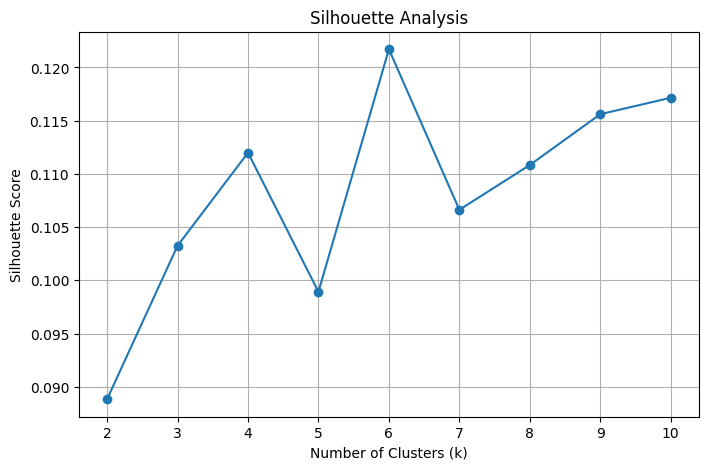

In [22]:
# ---- Silhouette Plot ----
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

plt.title('Silhouette Analysis')

plt.grid(True)

plt.show()


In [23]:
# ---------------------------------------------------------
# 2. Fit Final K-means Model
# ---------------------------------------------------------
k = 6
kmeans_final = KMeans(
    n_clusters=k,
    random_state=2026,
    n_init=25
)

clusters = kmeans_final.fit_predict(medical_clean)

# Add cluster labels
medical_clean['Cluster'] = clusters

df['Cluster'] = clusters

print("\nCluster counts")
print(df['Cluster'].value_counts())



Cluster counts
Cluster
1    92
2    83
0    20
5    15
4     6
3     4
Name: count, dtype: int64


In [24]:
# ---------------------------------------------------------
# 3. Cluster Characterization
# ---------------------------------------------------------

# Cluster sizes
cluster_sizes = df['Cluster'].value_counts().sort_index()

cluster_percent = (
    cluster_sizes / len(df)
) * 100

cluster_summary = pd.DataFrame({
    'Count': cluster_sizes,
    'Percent': cluster_percent
})

print("\nCLUSTER SIZE SUMMARY")
display(cluster_summary)

# Mean ± SD for numeric variables
numeric_cols_original = df.select_dtypes(
    include=np.number
).columns

cluster_characteristics = df.groupby('Cluster')[
    numeric_cols_original
].agg(['mean','std'])

print("\nCLUSTER CHARACTERISTICS")
display(cluster_characteristics)



CLUSTER SIZE SUMMARY


,Count,Percent
Cluster,,
0,20,9.090909
1,92,41.818182
2,83,37.727273
3,4,1.818182
4,6,2.727273
5,15,6.818182



CLUSTER CHARACTERISTICS


age                   bmi              waist_cm            \
              mean        std       mean       std        mean       std   
Cluster                                                                    
0        52.150000  15.187512  29.240000  5.092838  140.000000  0.000000   
1        50.799674  14.356442  28.927337  8.082783  139.851087  0.726802   
2        54.294337  12.827047  29.640349  8.432204  139.981928  0.112775   
3        48.750000  12.284814  24.712500  5.729220  137.100000  5.800000   
4        55.500000   6.978539  25.883333  4.640438  140.000000  0.000000   
5        52.733333  12.555401  19.639200  3.113503  128.945667  3.166068   

        bp_systolic            bp_diastolic             ...  \
               mean        std         mean        std  ...   
Cluster                                                 ...   
0        133.400000  21.345282    87.600000  15.191410  ...   
1        128.250000  15.472503    87.654239  12.096861  ...   
2        125.102410  22.852491    84.554217  12.900419  ...   
3        132.250000  38.221940    88.250000  21.171915  ...   
4        448.323000  49.495087    86.333333  15.344923  ...   
5        128.066667  19.129135    88.958667  13.843530  ...   

        alcohol_drinks_week           physical_activity_min_week              \
                       mean       std                       mean         std   
Cluster                                                                        
0                  3.700000  1.976174                 105.700000   88.686972   
1                  4.354565  2.051390                 209.532935  252.174937   
2                  4.732651  2.107488                 172.879518  164.282728   
3                  5.000000  2.943920                 276.750000  288.944487   
4                  4.666667  1.966384                  93.666667   73.282103   
5                  4.466667  2.386470                 231.200000  222.765476   

        risk_score           metabolic_syndrome           Cluster       
              mean       std               mean       std    mean  std  
Cluster                                                                 
0         7.159300  3.776146           0.550000  0.510418     0.0  0.0  
1         6.177228  3.335455           0.467391  0.501669     1.0  0.0  
2         6.905277  3.138071           0.469880  0.502126     2.0  0.0  
3         7.221500  5.891450           0.500000  0.577350     3.0  0.0  
4         9.016667  2.513497           0.666667  0.516398     4.0  0.0  
5         6.420000  3.077383           0.733333  0.457738     5.0  0.0  

[6 rows x 36 columns]

In [25]:
# ---------------------------------------------------------
# Top distinguishing features using ANOVA
# ---------------------------------------------------------

anova_results = {}

for col in cluster_features:

    groups = [
        df[df['Cluster']==c][col]
        for c in sorted(df['Cluster'].unique())
    ]

    f_stat, p_val = f_oneway(*groups)

    anova_results[col] = f_stat

anova_table = pd.DataFrame.from_dict(
    anova_results,
    orient='index',
    columns=['F_statistic']
)

anova_table = anova_table.sort_values(
    by='F_statistic',
    ascending=False
)

print("\nTOP DISTINGUISHING FEATURES")
display(anova_table.head(3))



TOP DISTINGUISHING FEATURES


,F_statistic
bp_systolic,271.056139
waist_cm,250.584371
glucose_fasting,102.766559


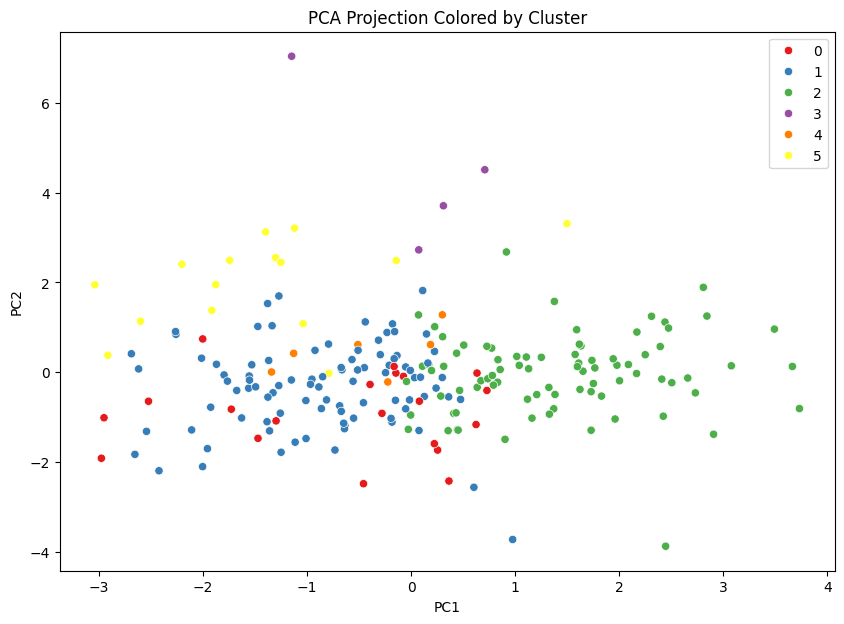

In [26]:
# ---------------------------------------------------------
# 4A. PCA Plot Colored by Cluster
# ---------------------------------------------------------

plt.figure(figsize=(10,7))

sns.scatterplot(
    x=pca_data[:,0],
    y=pca_data[:,1],
    hue=clusters,
    palette='Set1'
)

plt.xlabel('PC1')
plt.ylabel('PC2')

plt.title('PCA Projection Colored by Cluster')

plt.show()

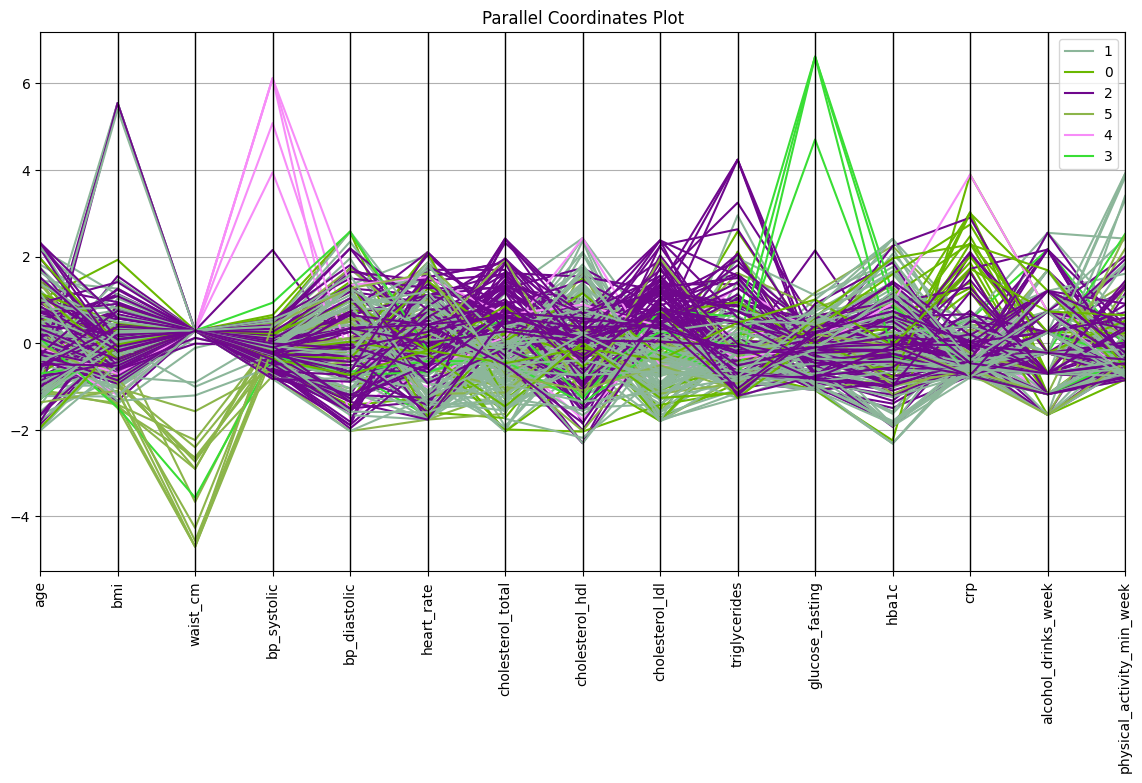

In [27]:
# ---------------------------------------------------------
# 4B. Parallel Coordinates Plot
# ---------------------------------------------------------
from pandas.plotting import parallel_coordinates
parallel_df = medical_clean.copy()

parallel_df['Cluster'] = parallel_df['Cluster'].astype(str)

plt.figure(figsize=(14,7))

parallel_coordinates(
    parallel_df.sample(min(200, len(parallel_df))),
    'Cluster'
)

plt.title('Parallel Coordinates Plot')

plt.xticks(rotation=90)

plt.show()




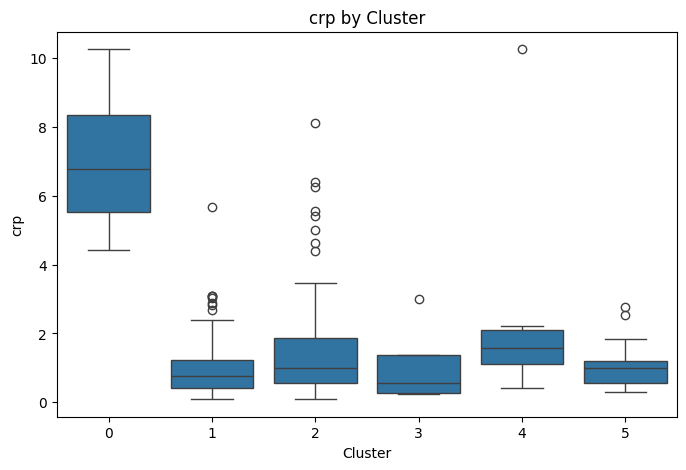

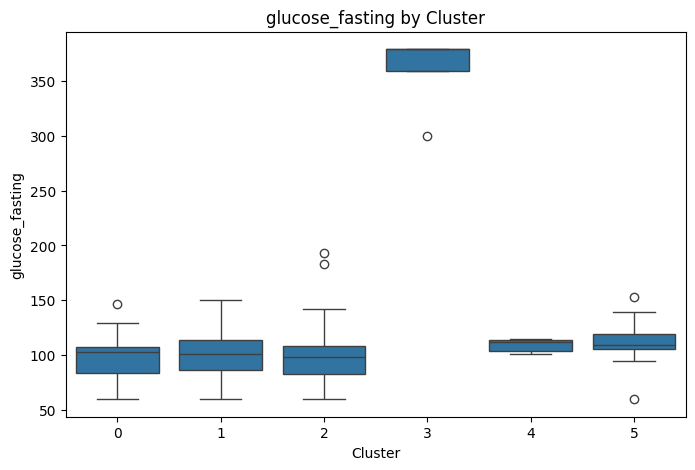

In [28]:
# ---------------------------------------------------------
# 4C. Cluster-wise Boxplots
# ---------------------------------------------------------

biomarkers = [
    'hbalc',
    'crp',
    'glucose_fasting'
]

biomarkers = [b for b in biomarkers if b in df.columns]

for biomarker in biomarkers:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        x='Cluster',
        y=biomarker,
        data=df
    )

    plt.title(f'{biomarker} by Cluster')

    plt.show()



In [29]:
# ---------------------------------------------------------
# 5. External Validation
# ---------------------------------------------------------

# ---- Chi-square test ----
if 'metabolic_syndrome' in df.columns:

    contingency = pd.crosstab(
        df['Cluster'],
        df['metabolic_syndrome']
    )

    chi2, p, dof, expected = chi2_contingency(contingency)

    print("\nCHI-SQUARE TEST")
    print(f"Chi-square statistic: {chi2:.3f}")
    print(f"p-value: {p:.5f}")

# ---- Risk score ANOVA ----
if 'risk_score' in df.columns:

    risk_groups = [
        df[df['Cluster']==c]['risk_score']
        for c in sorted(df['Cluster'].unique())
    ]

    f_stat, p_val = f_oneway(*risk_groups)

    print("\nANOVA FOR RISK SCORE")
    print(f"F-statistic: {f_stat:.3f}")
    print(f"p-value: {p_val:.5f}")


CHI-SQUARE TEST
Chi-square statistic: 4.826
p-value: 0.43750

ANOVA FOR RISK SCORE
F-statistic: 1.213
p-value: 0.30403
